In [ ]:
import pandas as pd

file25 = "5. CY2025_Landscape_202506.1.csv"
file26 = "2. CY2026_Landscape_202603.csv"

df25 = pd.read_csv(file25, dtype=str)
df26 = pd.read_csv(file26, dtype=str)

print(df25.shape, df26.shape)
df25.head(2)

(142653, 48) (138263, 52)


,Contract Year,Contract Category Type,State Abbreviation,State Name,County Name,Contract ID,Plan ID,Segment ID,Sanctioned Plan,Contract Name,...,Part C Premium,Monthly Consolidated Premium (Part C + D),In-Network Maximum Out-of-Pocket (MOOP) Amount,Part C Summary Star Rating,Part D Summary Star Rating,Overall Star Rating,MA Region Code,MA Region,PDP Region Code,PDP Region
0,2025,PDP,AK,Alaska,All Counties,S4802,096,0,No,"WELLCARE PRESCRIPTION INSURANCE, INC.",...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,3.5,Not Applicable,Not Applicable,Not Applicable,34,Alaska
1,2025,PDP,AK,Alaska,All Counties,S4802,165,0,No,"WELLCARE PRESCRIPTION INSURANCE, INC.",...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,3.5,Not Applicable,Not Applicable,Not Applicable,34,Alaska


In [ ]:
def norm_text(s):
    return (s.astype(str)
              .str.upper()
              .str.strip()
              .str.replace(r"\s+", " ", regex=True))

# Standardize state field names
df25 = df25.rename(columns={
    "State Abbreviation": "state_abbr",
    "State Name": "state_name"
})
df26 = df26.rename(columns={
    "State Territory Abbreviation": "state_abbr",
    "State Territory Name": "state_name"
})

# Normalize state/county/parent org names
df25["state_abbr"] = norm_text(df25["state_abbr"])
df26["state_abbr"] = norm_text(df26["state_abbr"])

df25["county_norm"] = norm_text(df25["County Name"])
df26["county_norm"] = norm_text(df26["County Name"])

df25["parent_org_norm"] = norm_text(df25["Parent Organization Name"])
df26["parent_org_norm"] = norm_text(df26["Parent Organization Name"])

In [ ]:
import pandas as pd

keys_mkt = ["state_abbr", "county_norm", "parent_org_norm"]

# 2025/2026 presence（market层：county+parent）
m25 = df25[keys_mkt].drop_duplicates().assign(present_2025=1)
m26 = df26[keys_mkt].drop_duplicates().assign(present_2026=1)

# Market-level exit: present in 2025, absent in 2026
exit_mkt = (m25.merge(m26, on=keys_mkt, how="left")
              .query("present_2026.isna()", engine="python")
              .drop(columns=["present_2026"]))
print("Exit market rows:", exit_mkt.shape[0])
exit_mkt.head()

Exit market rows: 1644


,state_abbr,county_norm,parent_org_norm,present_2025
464,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1
470,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1
471,AR,ASHLEY,USABLE MUTUAL INSURANCE COMPANY,1
482,AR,BENTON,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1
489,AR,BOONE,CVS HEALTH CORPORATION,1


In [ ]:
#Contract+Plan
if "ContractPlanID" not in df25.columns:
    df25["ContractPlanID"] = (
        df25["Contract ID"].astype(str).str.strip() + "-" +
        df25["Plan ID"].astype(str).str.strip()
    )

# 2025在每个county-parent下的规模统计
exit_size_25 = (df25.groupby(keys_mkt)
                  .agg(n_contracts_2025=("Contract ID", "nunique"),
                       n_contractplan_2025=("ContractPlanID", "nunique"),
                       n_planid_2025=("Plan ID", "nunique"))
                  .reset_index())

exit_table_A = (exit_mkt.merge(exit_size_25, on=keys_mkt, how="left")
                       .sort_values(["state_abbr","county_norm","parent_org_norm"]))

exit_table_A.head(10)

,state_abbr,county_norm,parent_org_norm,present_2025,n_contracts_2025,n_contractplan_2025,n_planid_2025
0,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
1,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
2,AR,ASHLEY,USABLE MUTUAL INSURANCE COMPANY,1,2,5,5
3,AR,BENTON,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
4,AR,BOONE,CVS HEALTH CORPORATION,1,1,7,7
5,AR,BRADLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
6,AR,CALHOUN,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
7,AR,CARROLL,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
8,AR,CHICOT,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
9,AR,CLARK,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4


In [ ]:
lookup25 = (df25[["state_abbr","county_norm","parent_org_norm","County Name","Parent Organization Name"]]
            .drop_duplicates(subset=["state_abbr","county_norm","parent_org_norm"]))

exit_table_A = exit_table_A.merge(lookup25, on=keys_mkt, how="left")

exit_table_A = exit_table_A[[
    "state_abbr","County Name","Parent Organization Name",
    "n_contracts_2025","n_contractplan_2025","n_planid_2025"
]]

exit_table_A.head(20)

,state_abbr,County Name,Parent Organization Name,n_contracts_2025,n_contractplan_2025,n_planid_2025
0,AR,Arkansas,Louisiana Health Service & Indemnity Company,1,4,4
1,AR,Ashley,Louisiana Health Service & Indemnity Company,1,4,4
2,AR,Ashley,USAble Mutual Insurance Company,2,5,5
3,AR,Benton,Louisiana Health Service & Indemnity Company,1,4,4
4,AR,Boone,CVS Health Corporation,1,7,7
5,AR,Bradley,Louisiana Health Service & Indemnity Company,1,4,4
6,AR,Calhoun,Louisiana Health Service & Indemnity Company,1,4,4
7,AR,Carroll,Louisiana Health Service & Indemnity Company,1,4,4
8,AR,Chicot,Louisiana Health Service & Indemnity Company,1,4,4
9,AR,Clark,Louisiana Health Service & Indemnity Company,1,4,4


In [ ]:

detail_cols = ["state_abbr","county_norm","parent_org_norm",
               "Contract ID","Plan ID","Segment ID",
               "Plan Name","Plan Type","SNP Type","Part D Coverage Indicator",
               "Part C Premium","Monthly Consolidated Premium (Part C + D)",
               "In-Network Maximum Out-of-Pocket (MOOP) Amount",
               "Overall Star Rating"]

# Some columns may not exist in 2025 or have slightly different names
detail_cols_exist = [c for c in detail_cols if c in df25.columns]

exit_detail_B = (df25.merge(exit_mkt[keys_mkt], on=keys_mkt, how="inner")
                   [detail_cols_exist]
                   .drop_duplicates()
                   .sort_values(["state_abbr","county_norm","parent_org_norm","Contract ID","Plan ID","Segment ID"]))

# Add back original display names
exit_detail_B = exit_detail_B.merge(
    df25[["state_abbr","county_norm","parent_org_norm","County Name","Parent Organization Name"]]
      .drop_duplicates(subset=keys_mkt),
    on=keys_mkt, how="left"
)

exit_detail_B.head(20)

,state_abbr,county_norm,parent_org_norm,Contract ID,Plan ID,Segment ID,Plan Name,Plan Type,SNP Type,Part D Coverage Indicator,Part C Premium,Monthly Consolidated Premium (Part C + D),In-Network Maximum Out-of-Pocket (MOOP) Amount,Overall Star Rating,County Name,Parent Organization Name
0,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,002,0,Primewell Classic (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$4,500.00",3,Arkansas,Louisiana Health Service & Indemnity Company
1,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,003,0,Primewell Dual Plus (HMO-POS D-SNP),HMO-POS D-SNP,Dual-Eligible,Yes,$0.00,$20.90,"$9,350.00",3,Arkansas,Louisiana Health Service & Indemnity Company
2,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,004,0,Primewell Reliance (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$20.90,"$4,100.00",3,Arkansas,Louisiana Health Service & Indemnity Company
3,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,005,0,Primewell Giveback (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$5,400.00",3,Arkansas,Louisiana Health Service & Indemnity Company
4,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,002,0,Primewell Classic (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$4,500.00",3,Ashley,Louisiana Health Service & Indemnity Company
5,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,003,0,Primewell Dual Plus (HMO-POS D-SNP),HMO-POS D-SNP,Dual-Eligible,Yes,$0.00,$20.90,"$9,350.00",3,Ashley,Louisiana Health Service & Indemnity Company
6,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,004,0,Primewell Reliance (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$20.90,"$4,100.00",3,Ashley,Louisiana Health Service & Indemnity Company
7,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,005,0,Primewell Giveback (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$5,400.00",3,Ashley,Louisiana Health Service & Indemnity Company
8,AR,ASHLEY,USABLE MUTUAL INSURANCE COMPANY,H3554,002,0,BlueMedicare Saver Choice (PPO),PPO,Not Applicable,Yes,$0.00,$0.00,"$6,000.00",3,Ashley,USAble Mutual Insurance Company
9,AR,ASHLEY,USABLE MUTUAL INSURANCE COMPANY,H3554,007,0,BlueMedicare Premier Choice (PPO),PPO,Not Applicable,Yes,$33.70,$49.00,"$5,700.00",3,Ashley,USAble Mutual Insurance Company


In [ ]:
exit_by_county = (exit_table_A.groupby(["state_abbr","County Name"])
                            .agg(num_exiting_carriers=("Parent Organization Name","nunique"))
                            .reset_index()
                            .sort_values("num_exiting_carriers", ascending=False))

exit_by_county.head(20)

,state_abbr,County Name,num_exiting_carriers
547,MN,Red Lake,4
499,MN,Clearwater,4
527,MN,Mahnomen,4
535,MN,Murray,4
537,MN,Nobles,4
538,MN,Norman,4
540,MN,Otter Tail,4
541,MN,Pennington,4
543,MN,Pipestone,4
544,MN,Polk,4


In [ ]:
# Optional: save data
exit_table_A.to_csv("exit_county_parentorg_2025_only.csv", index=False)
exit_detail_B.to_csv("exit_county_parentorg_plan_detail_2025_only.csv", index=False)
exit_by_county.to_csv("exit_by_county_num_exiting_carriers.csv", index=False)

#from google.colab import files
#files.download("exit_county_parentorg_2025_only.csv")
#files.download("exit_county_parentorg_plan_detail_2025_only.csv")
#files.download("exit_by_county_num_exiting_carriers.csv")

In [ ]:
# Optional: save data
exit_detail_B.to_parquet("exit_detail_B.parquet", index=False)

#from google.colab import files
#files.download("exit_detail_B.parquet")

In [ ]:
import pandas as pd
import re

files_2025 = [
  "SCC_Enrollment_MA_2025_01.csv","SCC_Enrollment_MA_2025_02.csv",
  "SCC_Enrollment_MA_2025_03.csv","SCC_Enrollment_MA_2025_04.csv",
  "SCC_Enrollment_MA_2025_05.csv","SCC_Enrollment_MA_2025_06.csv",
  "SCC_Enrollment_MA_2025_07.csv","SCC_Enrollment_MA_2025_08.csv",
  "SCC_Enrollment_MA_2025_09.csv","SCC_Enrollment_MA_2025_10.csv",
  "SCC_Enrollment_MA_2025_11.csv","SCC_Enrollment_MA_2025_12.csv"
]
files_2026 = ["SCC_Enrollment_MA_2026_01.csv","SCC_Enrollment_MA_2026_02.csv","SCC_Enrollment_MA_2026_03.csv"]

def clean_enrolled(x):
    x = x.astype(str).str.strip().replace({".": None, "": None})
    return pd.to_numeric(x, errors="coerce").fillna(0).astype(int)

def norm_county(s):
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    # Standardize abbreviations
    s = s.str.replace(r"\bST\.\b", "SAINT", regex=True)
    s = s.str.replace(r"\bSTE\.\b", "SAINTE", regex=True)
    # Remove suffixes
    s = s.str.replace(r"\bCOUNTY\b", "", regex=True)
    s = s.str.replace(r"\bPARISH\b", "", regex=True)
    s = s.str.replace(r"\bBOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCENSUS AREA\b", "", regex=True)
    s = s.str.replace(r"\bCITY AND BOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCITY\b", "", regex=True)
    # Remove punctuation
    s = s.str.replace(r"[^\w\s]", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def read_enrollment(fp):
    df = pd.read_csv(fp, dtype=str)
    df.columns = df.columns.str.strip()

    m = re.search(r"(20\d{2})[_-](\d{2})", fp)
    period = f"{m.group(1)}-{m.group(2)}" if m else fp

    df["period"] = period
    df["state_abbr"] = df["State"].astype(str).str.upper().str.strip()
    df["county_norm"] = norm_county(df["County"])
    df["Contract ID"] = df["Contract ID"].astype(str).str.upper().str.strip()
    df["Enrolled"] = clean_enrolled(df["Enrolled"])
    return df

enr_all = pd.concat([read_enrollment(f) for f in (files_2025 + files_2026)], ignore_index=True)
print("enr_all shape:", enr_all.shape)
enr_all.head(2)

enr_all shape: (6872628, 12)


,County,State,Contract ID,Organization Name,Organization Type,Plan Type,SSA Code,FIPS Code,Enrolled,period,state_abbr,county_norm
0,Autauga,AL,90091,UNITED MINE WORKERS OF AMERICA HLTH & RETIREMENT,HCPP - 1833 Cost,HCPP - 1833 Cost,01000,01001,0,2025-01,AL,AUTAUGA
1,Autauga,AL,H0104,BLUE CROSS AND BLUE SHIELD OF ALABAMA,Local CCP,Local PPO,01000,01001,946,2025-01,AL,AUTAUGA


In [ ]:
cw25_path = "1. ACHP_Members_Crosswalk_2025_JHU (List of ACHP Member Plans).xlsx"
cw26_path = "1. ACHP_Members_Crosswalk_2026_JHU (List of ACHP Member Plans).xlsx"

cw25 = pd.read_excel(cw25_path, dtype=str)
cw26 = pd.read_excel(cw26_path, dtype=str)
cw25.columns = cw25.columns.str.strip()
cw26.columns = cw26.columns.str.strip()

cw_all = pd.concat([cw25, cw26], ignore_index=True)
cw_all["Contract ID"] = cw_all["Contract ID"].astype(str).str.upper().str.strip()

achp_contracts = set(cw_all["Contract ID"].dropna().unique())
print("Num ACHP contracts in crosswalk:", len(achp_contracts))

enr_all["is_achp"] = enr_all["Contract ID"].isin(achp_contracts)
print(enr_all["is_achp"].value_counts())

Num ACHP contracts in crosswalk: 96
is_achp
False    5890999
True      981629
Name: count, dtype: int64


In [ ]:
exit_df = exit_mkt

exit_df = exit_df.copy()
exit_df["state_abbr"] = exit_df["state_abbr"].astype(str).str.upper().str.strip()
exit_df["county_norm"] = norm_county(exit_df["county_norm"])

exit_counties = exit_df[["state_abbr","county_norm"]].drop_duplicates()
print("num exit counties:", len(exit_counties))

exit_pairs = set(zip(exit_counties["state_abbr"], exit_counties["county_norm"]))
enr_all["is_exit_county"] = list(zip(enr_all["state_abbr"], enr_all["county_norm"]))
enr_all["is_exit_county"] = enr_all["is_exit_county"].isin(exit_pairs)

enr_all["is_exit_county"].value_counts()

num exit counties: 1262


is_exit_county
False    4272552
True     2600076
Name: count, dtype: int64

In [ ]:
def market_trend(df, exit_flag=True):
    d = df[df["is_exit_county"]==exit_flag].copy()
    total = d.groupby("period")["Enrolled"].sum().reset_index(name="total_enrolled")
    achp  = d[d["is_achp"]].groupby("period")["Enrolled"].sum().reset_index(name="achp_enrolled")
    out = total.merge(achp, on="period", how="left").fillna(0)
    out["achp_share"] = out["achp_enrolled"] / out["total_enrolled"].replace({0: pd.NA})
    out["market_type"] = "exit_counties" if exit_flag else "non_exit_counties"
    return out.sort_values("period")

trend_exit = market_trend(enr_all, True)
trend_non  = market_trend(enr_all, False)

trend_exit

,period,total_enrolled,achp_enrolled,achp_share,market_type
0,2025-01,11944734,1227038,0.102726,exit_counties
1,2025-02,12125788,1239251,0.102200,exit_counties
2,2025-03,12187794,1242258,0.101926,exit_counties
3,2025-04,12218428,1243647,0.101785,exit_counties
4,2025-05,12250087,1246349,0.101742,exit_counties
5,2025-06,12292963,1248420,0.101556,exit_counties
6,2025-07,12320585,1251155,0.101550,exit_counties
7,2025-08,12355039,1254557,0.101542,exit_counties
8,2025-09,12372663,1257218,0.101613,exit_counties
9,2025-10,12384051,1259820,0.101729,exit_counties


In [ ]:
trend_all = pd.concat([trend_exit, trend_non], ignore_index=True)
display(trend_all.head())

,period,total_enrolled,achp_enrolled,achp_share,market_type
0,2025-01,11944734,1227038,0.102726,exit_counties
1,2025-02,12125788,1239251,0.102200,exit_counties
2,2025-03,12187794,1242258,0.101926,exit_counties
3,2025-04,12218428,1243647,0.101785,exit_counties
4,2025-05,12250087,1246349,0.101742,exit_counties


In [ ]:
def county_snapshot(df):
    total = df.groupby(["state_abbr","county_norm"])["Enrolled"].sum().reset_index(name="total")
    achp  = df[df["is_achp"]].groupby(["state_abbr","county_norm"])["Enrolled"].sum().reset_index(name="achp")
    out = total.merge(achp, on=["state_abbr","county_norm"], how="left").fillna(0)
    out["achp_share"] = out["achp"] / out["total"].replace({0: pd.NA})
    return out

base = enr_all[(enr_all["period"]=="2025-12") & (enr_all["is_exit_county"])]
post = enr_all[(enr_all["period"]=="2026-03") & (enr_all["is_exit_county"])]

c_base = county_snapshot(base).rename(columns={"total":"total_2025_12","achp":"achp_2025_12","achp_share":"share_2025_12"})
c_post = county_snapshot(post).rename(columns={"total":"total_2026_03","achp":"achp_2026_03","achp_share":"share_2026_03"})

county_change_exit = c_base.merge(c_post, on=["state_abbr","county_norm"], how="outer").fillna(0)
county_change_exit["achp_delta"] = county_change_exit["achp_2026_03"] - county_change_exit["achp_2025_12"]
county_change_exit["share_delta"] = county_change_exit["share_2026_03"] - county_change_exit["share_2025_12"]

lookup = (enr_all[enr_all["period"]=="2026-03"][["state_abbr","county_norm","County"]]
          .drop_duplicates(subset=["state_abbr","county_norm"])
          .rename(columns={"County":"County Name"}))
county_change_exit = county_change_exit.merge(lookup, on=["state_abbr","county_norm"], how="left")

top_pickup = county_change_exit.sort_values("achp_delta", ascending=False).head(30)
top_pickup[["state_abbr","County Name","achp_2025_12","achp_2026_03","achp_delta","share_delta"]]

/var/folders/s7/j5wqf06d2bqfllwdjj1_xjvr0000gn/T/ipykernel_23054/2983366137.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  county_change_exit = c_base.merge(c_post, on=["state_abbr","county_norm"], how="outer").fillna(0)


,state_abbr,County Name,achp_2025_12,achp_2026_03,achp_delta,share_delta
502,MN,Hennepin,28851,38637,9786,0.091329
547,MN,St. Louis,6692,14321,7629,0.245771
1161,WI,Brown,10115,16825,6710,0.161443
530,MN,Olmsted,493,4176,3683,0.336545
1220,WI,Waukesha,6128,9723,3595,0.056041
1198,WI,Outagamie,13776,17268,3492,0.102982
971,SD,Minnehaha,7295,10677,3382,0.207949
1194,WI,Milwaukee,7186,10487,3301,0.028764
470,MI,Saginaw,6363,9425,3062,0.090724
499,MN,Freeborn,87,2652,2565,0.628303


In [ ]:
def total_delta(df, exit_flag=True, period0="2025-12", period1="2026-03"):
    d0 = df[(df["period"]==period0) & (df["is_exit_county"]==exit_flag)]
    d1 = df[(df["period"]==period1) & (df["is_exit_county"]==exit_flag)]
    achp0 = d0[d0["is_achp"]]["Enrolled"].sum()
    achp1 = d1[d1["is_achp"]]["Enrolled"].sum()
    tot0  = d0["Enrolled"].sum()
    tot1  = d1["Enrolled"].sum()
    return {
        "market_type": "exit_counties" if exit_flag else "non_exit_counties",
        "achp_2025_12": int(achp0),
        "achp_2026_03": int(achp1),
        "achp_delta": int(achp1-achp0),
        "share_2025_12": achp0/tot0 if tot0 else None,
        "share_2026_03": achp1/tot1 if tot1 else None,
        "share_delta": (achp1/tot1 - achp0/tot0) if (tot0 and tot1) else None
    }

summary = pd.DataFrame([total_delta(enr_all, True), total_delta(enr_all, False)])
summary

,market_type,achp_2025_12,achp_2026_03,achp_delta,share_2025_12,share_2026_03,share_delta
0,exit_counties,1268468,1368492,100024,0.102191,0.110410,0.008219
1,non_exit_counties,2343051,2435246,92195,0.101118,0.103889,0.002771


In [ ]:
import matplotlib.pyplot as plt

# share trend
plt.figure(figsize=(11,4))
for m, d in trend_all.groupby("market_type"):
    plt.plot(d["period"], d["achp_share"], marker="o", linewidth=2, label=m)
plt.xticks(rotation=45)
plt.ylabel("ACHP enrollment share")
plt.title("ACHP Share Trend: Exit Counties vs Non-Exit Counties (2025-01 to 2026-03)")
plt.legend()
plt.tight_layout()

plt.savefig("achp_share_trend_exit_vs_nonexit.png", dpi=300, bbox_inches="tight")
plt.close()

# enrollment trend
plt.figure(figsize=(11,4))
for m, d in trend_all.groupby("market_type"):
    plt.plot(d["period"], d["achp_enrolled"], marker="o", linewidth=2, label=m)
plt.xticks(rotation=45)
plt.ylabel("ACHP enrolled")
plt.title("ACHP Enrollment Trend: Exit Counties vs Non-Exit Counties (2025-01 to 2026-03)")
plt.legend()
plt.tight_layout()

plt.savefig("achp_enroll_trend_exit_vs_nonexit.png", dpi=300, bbox_inches="tight")
plt.close()

# 下载到本地
#files.download("achp_share_trend_exit_vs_nonexit.png")
#files.download("achp_enroll_trend_exit_vs_nonexit.png")

## Analysis H1: What Drives ACHP Pickup?

### Part 1 — Exit Intensity vs ACHP Share Gain
Tests whether counties with more exiting carriers show higher ACHP share gains.
- **X-axis**: number of carriers that exited each county (1–4)
- **Y-axis**: ACHP share change between 2025-12 and 2026-03 (share_delta)
- **Method**: scatter plot with linear regression line
- **Data source**: `scatter_df_viz` — merged from `county_change_exit` and `exit_by_county`

### Part 2 — Pre-Exit Star Ratings by Pickup Group
Tests whether counties with lower pre-exit quality show higher ACHP pickup.
- **Y-axis**: Overall Star Rating of exiting plans before exit (from `exit_detail_B`)
- **Groups**: High Pickup vs Low Pickup — defined by top/bottom 25% of share_delta
- **Method**: box plot comparing star rating distributions across pickup groups
- **Data source**: `box_df_viz` — merged from `exit_detail_B_viz` and `pickup_groups_viz`

### Key Definitions
- **High Pickup**: counties where share_delta >= 75th percentile
- **Low Pickup**: counties where share_delta <= 25th percentile
- **share_delta**: ACHP enrollment share in 2026-03 minus 2025-12

scatter_df_viz shape: (1252, 14)


,state_abbr,county_norm,num_exiting_carriers,share_delta,achp_delta
0,AR,ARKANSAS,1,0.0,0
1,AR,ASHLEY,2,0.0,0
2,AR,BENTON,1,0.0,0
3,AR,BOONE,1,0.0,0
4,AR,BRADLEY,1,0.0,0


pickup_groups_viz counts:
pickup_group
Low Pickup     907
High Pickup    312
Name: count, dtype: int64
Using star column: Overall Star Rating
box_df_viz shape: (6239, 20)


,state_abbr,county_norm,pickup_group,Overall Star Rating,star_num_viz
0,AR,ARKANSAS,Low Pickup,3,3.0
1,AR,ARKANSAS,Low Pickup,3,3.0
2,AR,ARKANSAS,Low Pickup,3,3.0
3,AR,ARKANSAS,Low Pickup,3,3.0
4,AR,ASHLEY,Low Pickup,3,3.0


Low Pickup star count: 3874
High Pickup star count: 2365


/var/folders/s7/j5wqf06d2bqfllwdjj1_xjvr0000gn/T/ipykernel_23054/3867687646.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


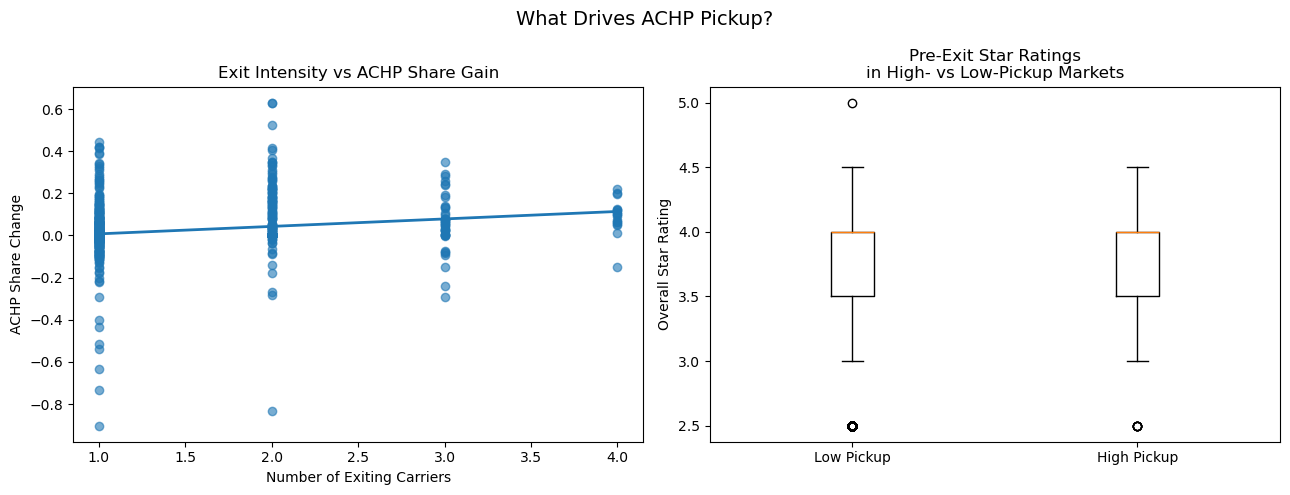

In [ ]:
# =========================
# What Drives ACHP Pickup?
#Exit Intensity vs ACHP Share Gain
#pre-exit Star Ratings in High- vs Low-Pickup Markets
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def norm_county_for_viz(s):
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    s = s.str.replace(r"\bST\.\b", "SAINT", regex=True)
    s = s.str.replace(r"\bSTE\.\b", "SAINTE", regex=True)
    s = s.str.replace(r"\bCOUNTY\b", "", regex=True)
    s = s.str.replace(r"\bPARISH\b", "", regex=True)
    s = s.str.replace(r"\bBOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCENSUS AREA\b", "", regex=True)
    s = s.str.replace(r"\bCITY AND BOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCITY\b", "", regex=True)
    s = s.str.replace(r"[^\w\s]", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def clean_numeric_for_viz(s):
    s = s.astype(str).str.strip()
    s = s.str.replace("$", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    s = s.replace({
        "Not Applicable": np.nan,
        "Not Available": np.nan,
        "nan": np.nan,
        "": np.nan
    })
    return pd.to_numeric(s, errors="coerce")



# 2.1 county_change_exit -> county_change_exit_viz
county_change_exit_viz = county_change_exit.copy()

county_change_exit_viz["state_abbr_viz"] = (
    county_change_exit_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

county_change_exit_viz["county_norm_viz"] = norm_county_for_viz(
    county_change_exit_viz["county_norm"]
)

# 2.2 exit_by_county -> exit_by_county_viz
exit_by_county_viz = exit_by_county.copy()

exit_by_county_viz["state_abbr_viz"] = (
    exit_by_county_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

exit_by_county_viz["county_norm_viz"] = norm_county_for_viz(
    exit_by_county_viz["County Name"]
)

# 2.3 exit_detail_B -> exit_detail_B_viz
exit_detail_B_viz = exit_detail_B.copy()

exit_detail_B_viz["state_abbr_viz"] = (
    exit_detail_B_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

exit_detail_B_viz["county_norm_viz"] = norm_county_for_viz(
    exit_detail_B_viz["county_norm"]
)


scatter_df_viz = county_change_exit_viz.merge(
    exit_by_county_viz[
        ["state_abbr_viz", "county_norm_viz", "num_exiting_carriers"]
    ],
    on=["state_abbr_viz", "county_norm_viz"],
    how="left"
)

scatter_df_viz = scatter_df_viz.dropna(
    subset=["num_exiting_carriers", "share_delta"]
).copy()

# Optional: check
print("scatter_df_viz shape:", scatter_df_viz.shape)
display(
    scatter_df_viz[
        ["state_abbr", "county_norm", "num_exiting_carriers", "share_delta", "achp_delta"]
    ].head()
)


pickup_groups_viz = county_change_exit.copy()

pickup_groups_viz["state_abbr_viz"] = (
    pickup_groups_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

pickup_groups_viz["county_norm_viz"] = norm_county_for_viz(
    pickup_groups_viz["county_norm"]
)

q75 = pickup_groups_viz["share_delta"].quantile(0.75)
q25 = pickup_groups_viz["share_delta"].quantile(0.25)

pickup_groups_viz["pickup_group"] = np.where(
    pickup_groups_viz["share_delta"] >= q75,
    "High Pickup",
    np.where(
        pickup_groups_viz["share_delta"] <= q25,
        "Low Pickup",
        "Middle"
    )
)

pickup_groups_viz = pickup_groups_viz[
    pickup_groups_viz["pickup_group"] != "Middle"
].copy()

print("pickup_groups_viz counts:")
print(pickup_groups_viz["pickup_group"].value_counts())


candidate_star_cols = [
    "Overall Star Rating",
    "Overall Star Rating ",
    "Part C Summary Star Rating",
    "Part C Summary Star Rating "
]

star_col = None
for c in candidate_star_cols:
    if c in exit_detail_B_viz.columns:
        star_col = c
        break

if star_col is None:
    raise ValueError("未找到 Star Rating 字段，请检查 exit_detail_B 的列名。")

exit_detail_B_viz["star_num_viz"] = clean_numeric_for_viz(
    exit_detail_B_viz[star_col]
)

print("Using star column:", star_col)

box_df_viz = exit_detail_B_viz.merge(
    pickup_groups_viz[
        ["state_abbr_viz", "county_norm_viz", "pickup_group"]
    ],
    on=["state_abbr_viz", "county_norm_viz"],
    how="inner"
)

box_df_viz = box_df_viz.dropna(
    subset=["star_num_viz", "pickup_group"]
).copy()

print("box_df_viz shape:", box_df_viz.shape)
display(
    box_df_viz[
        ["state_abbr", "county_norm", "pickup_group", star_col, "star_num_viz"]
    ].head()
)


low_star_viz = box_df_viz.loc[
    box_df_viz["pickup_group"] == "Low Pickup",
    "star_num_viz"
].copy()

high_star_viz = box_df_viz.loc[
    box_df_viz["pickup_group"] == "High Pickup",
    "star_num_viz"
].copy()

print("Low Pickup star count:", low_star_viz.shape[0])
print("High Pickup star count:", high_star_viz.shape[0])


fig, axes = plt.subplots(1, 2, figsize=(13, 5))


x = scatter_df_viz["num_exiting_carriers"].astype(float)
y = scatter_df_viz["share_delta"].astype(float)

axes[0].scatter(x, y, alpha=0.6)


if len(scatter_df_viz) > 1:
    coef = np.polyfit(x, y, 1)
    trend = np.poly1d(coef)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(x_line, trend(x_line), linewidth=2)

axes[0].set_xlabel("Number of Exiting Carriers")
axes[0].set_ylabel("ACHP Share Change")
axes[0].set_title("Exit Intensity vs ACHP Share Gain")


axes[1].boxplot(
    [low_star_viz, high_star_viz],
    labels=["Low Pickup", "High Pickup"]
)
axes[1].set_ylabel("Overall Star Rating")
axes[1].set_title("Pre-Exit Star Ratings\nin High- vs Low-Pickup Markets")

fig.suptitle("What Drives ACHP Pickup?", fontsize=14)
plt.tight_layout()


output_file = "achp_pickup_drivers.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()


#files.download(output_file)

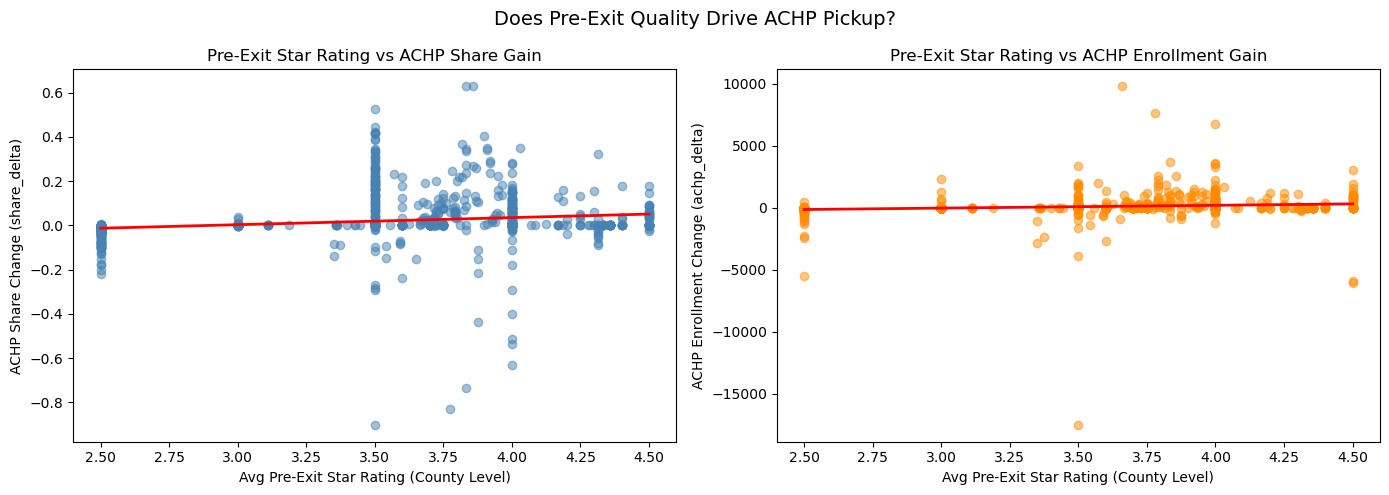

In [ ]:

#Pre-Exit Star Rating vs ACHP Share Change


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


star_by_county = (
    exit_detail_B_viz
    .dropna(subset=["star_num_viz"])
    .groupby(["state_abbr_viz", "county_norm_viz"])["star_num_viz"]
    .mean()
    .reset_index(name="avg_star_prexit")
)


star_vs_pickup = county_change_exit_viz.merge(
    star_by_county,
    on=["state_abbr_viz", "county_norm_viz"],
    how="inner"
).dropna(subset=["avg_star_prexit", "share_delta"])


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


x = star_vs_pickup["avg_star_prexit"]
y = star_vs_pickup["share_delta"]

axes[0].scatter(x, y, alpha=0.5, color="steelblue")
coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
axes[0].plot(x_line, np.poly1d(coef)(x_line), color="red", linewidth=2)
axes[0].set_xlabel("Avg Pre-Exit Star Rating (County Level)")
axes[0].set_ylabel("ACHP Share Change (share_delta)")
axes[0].set_title("Pre-Exit Star Rating vs ACHP Share Gain")

# 右图：Star Rating vs ACHP Enrollment Change (achp_delta)
y2 = star_vs_pickup["achp_delta"]
axes[1].scatter(x, y2, alpha=0.5, color="darkorange")
coef2 = np.polyfit(x, y2, 1)
axes[1].plot(x_line, np.poly1d(coef2)(x_line), color="red", linewidth=2)
axes[1].set_xlabel("Avg Pre-Exit Star Rating (County Level)")
axes[1].set_ylabel("ACHP Enrollment Change (achp_delta)")
axes[1].set_title("Pre-Exit Star Rating vs ACHP Enrollment Gain")

fig.suptitle("Does Pre-Exit Quality Drive ACHP Pickup?", fontsize=14)
plt.tight_layout()
plt.savefig("star_rating_vs_pickup.png", dpi=300, bbox_inches="tight")
plt.show()

pickup_groups_viz counts:
pickup_group
Low Pickup     907
High Pickup    312
Name: count, dtype: int64


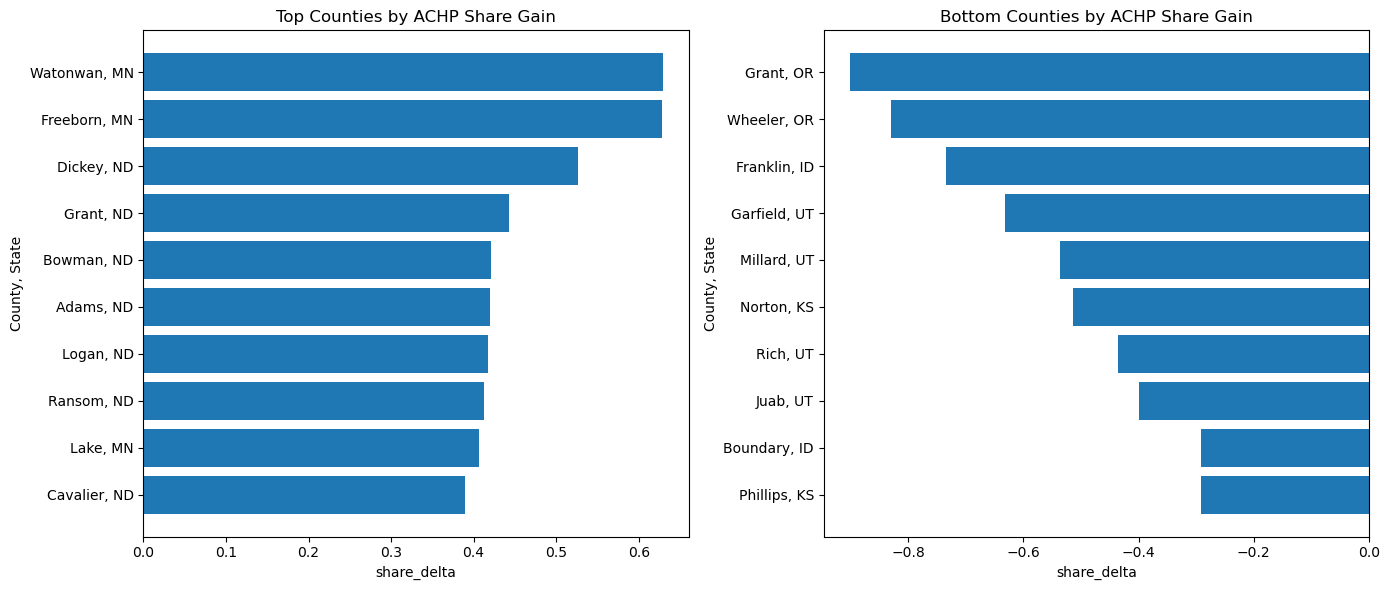

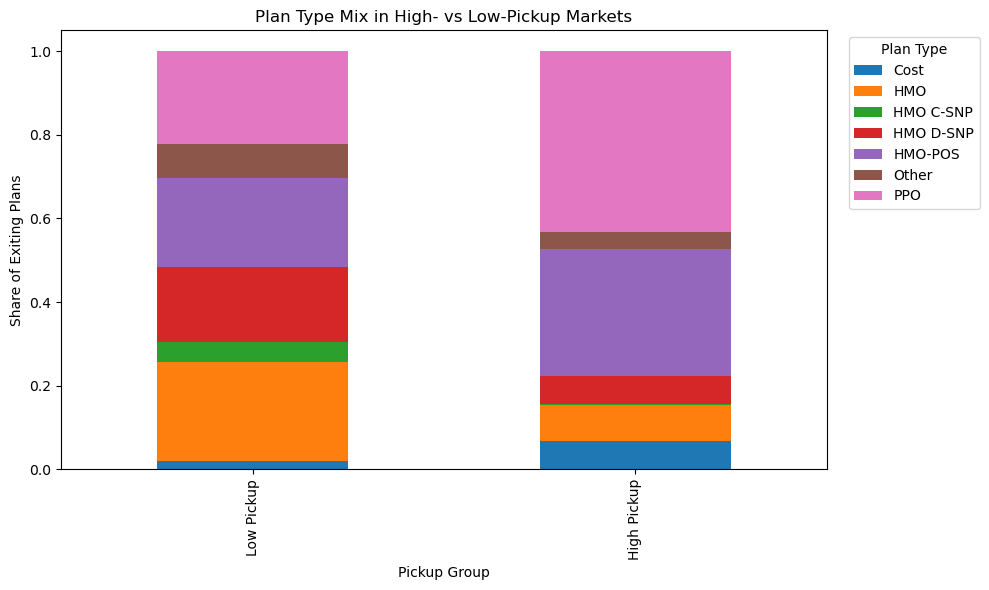

In [ ]:

# Page 4 charts
# A) Top / Bottom Counties by ACHP Share Gain
# B) Plan Type Mix in High- vs Low-Pickup Markets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



def norm_county_for_viz(s):
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    s = s.str.replace(r"\bST\.\b", "SAINT", regex=True)
    s = s.str.replace(r"\bSTE\.\b", "SAINTE", regex=True)
    s = s.str.replace(r"\bCOUNTY\b", "", regex=True)
    s = s.str.replace(r"\bPARISH\b", "", regex=True)
    s = s.str.replace(r"\bBOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCENSUS AREA\b", "", regex=True)
    s = s.str.replace(r"\bCITY AND BOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCITY\b", "", regex=True)
    s = s.str.replace(r"[^\w\s]", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s



# 1.1 county_change_exit -> county_change_exit_viz
county_change_exit_viz = county_change_exit.copy()

county_change_exit_viz["state_abbr_viz"] = (
    county_change_exit_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

county_change_exit_viz["county_norm_viz"] = norm_county_for_viz(
    county_change_exit_viz["county_norm"]
)


if "County Name" not in county_change_exit_viz.columns:
    county_change_exit_viz["County Name"] = county_change_exit_viz["county_norm"]

county_change_exit_viz["county_label_viz"] = (
    county_change_exit_viz["County Name"].astype(str).str.strip()
    + ", "
    + county_change_exit_viz["state_abbr"].astype(str).str.strip()
)

# 1.2 exit_detail_B -> exit_detail_B_viz
exit_detail_B_viz = exit_detail_B.copy()

exit_detail_B_viz["state_abbr_viz"] = (
    exit_detail_B_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

exit_detail_B_viz["county_norm_viz"] = norm_county_for_viz(
    exit_detail_B_viz["county_norm"]
)


pickup_groups_viz = county_change_exit_viz.copy()

q75 = pickup_groups_viz["share_delta"].quantile(0.75)
q25 = pickup_groups_viz["share_delta"].quantile(0.25)

pickup_groups_viz["pickup_group"] = np.where(
    pickup_groups_viz["share_delta"] >= q75,
    "High Pickup",
    np.where(
        pickup_groups_viz["share_delta"] <= q25,
        "Low Pickup",
        "Middle"
    )
)

pickup_groups_viz = pickup_groups_viz[
    pickup_groups_viz["pickup_group"] != "Middle"
].copy()

print("pickup_groups_viz counts:")
print(pickup_groups_viz["pickup_group"].value_counts())


# Top / Bottom Counties by ACHP Share Gain

county_rank_viz = county_change_exit_viz.copy()


county_rank_viz = county_rank_viz.dropna(subset=["share_delta"]).copy()

top_n = 10

top_counties_viz = (
    county_rank_viz
    .sort_values("share_delta", ascending=False)
    .head(top_n)
    .copy()
)

bottom_counties_viz = (
    county_rank_viz
    .sort_values("share_delta", ascending=True)
    .head(top_n)
    .copy()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].barh(
    top_counties_viz["county_label_viz"][::-1],
    top_counties_viz["share_delta"][::-1]
)
axes[0].set_title("Top Counties by ACHP Share Gain")
axes[0].set_xlabel("share_delta")
axes[0].set_ylabel("County, State")


axes[1].barh(
    bottom_counties_viz["county_label_viz"][::-1],
    bottom_counties_viz["share_delta"][::-1]
)
axes[1].set_title("Bottom Counties by ACHP Share Gain")
axes[1].set_xlabel("share_delta")
axes[1].set_ylabel("County, State")

plt.tight_layout()
plt.savefig("top_bottom_counties_share_gain.png", dpi=300, bbox_inches="tight")
plt.show()


# Plan Type Mix in High- vs Low-Pickup Markets

# 寻找 Plan Type 字段
plan_type_col = None
for c in ["Plan Type", "Plan Type "]:
    if c in exit_detail_B_viz.columns:
        plan_type_col = c
        break

if plan_type_col is None:
    raise ValueError("未找到 Plan Type 字段，请检查 exit_detail_B 的列名。")

# Merge pickup groups到计划明细
detail_pickup_viz = exit_detail_B_viz.merge(
    pickup_groups_viz[
        ["state_abbr_viz", "county_norm_viz", "pickup_group"]
    ],
    on=["state_abbr_viz", "county_norm_viz"],
    how="inner"
)

# 清洗/归并 Plan Type
plan_type_mix_viz = detail_pickup_viz.copy()

plan_type_mix_viz["plan_type_viz"] = (
    plan_type_mix_viz[plan_type_col]
    .astype(str)
    .str.strip()
    .replace({"": "Unknown", "nan": "Unknown"})
)

# 只保留出现频率最高的前 6 类，其余并成 Other
top_types = (
    plan_type_mix_viz["plan_type_viz"]
    .value_counts()
    .head(6)
    .index
    .tolist()
)

plan_type_mix_viz["plan_type_grouped_viz"] = np.where(
    plan_type_mix_viz["plan_type_viz"].isin(top_types),
    plan_type_mix_viz["plan_type_viz"],
    "Other"
)

# 生成占比表
plan_type_tab_viz = pd.crosstab(
    plan_type_mix_viz["pickup_group"],
    plan_type_mix_viz["plan_type_grouped_viz"],
    normalize="index"
)

# 保证显示顺序
desired_index = [i for i in ["Low Pickup", "High Pickup"] if i in plan_type_tab_viz.index]
plan_type_tab_viz = plan_type_tab_viz.loc[desired_index]

ax = plan_type_tab_viz.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("Plan Type Mix in High- vs Low-Pickup Markets")
ax.set_xlabel("Pickup Group")
ax.set_ylabel("Share of Exiting Plans")

plt.legend(title="Plan Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("plan_type_mix_high_vs_low_pickup.png", dpi=300, bbox_inches="tight")
plt.show()


#files.download("top_bottom_counties_share_gain.png")
#files.download("plan_type_mix_high_vs_low_pickup.png")

In [ ]:
# Extract Premium and MOOP for ACHP and non-ACHP from df25/df26
# Group by exit_county / non_exit_county
premium_cols = ["Part C Premium",
                "Monthly Consolidated Premium (Part C + D)",
                "In-Network Maximum Out-of-Pocket (MOOP) Amount"]

def clean_premium(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(
                df[c].astype(str).str.replace("$","").str.replace(",",""),
                errors="coerce"
            )
    return df

df25_clean = clean_premium(df25.copy(), premium_cols)
df26_clean = clean_premium(df26.copy(), premium_cols)

# Flag whether ACHP and whether exit county
df25_clean["is_achp"] = df25_clean["Contract ID"].isin(achp_contracts)
df25_clean["is_exit"] = list(zip(df25_clean["state_abbr"], df25_clean["county_norm"]))
# ...Subsequent groupby to compare mean/min/max

In [ ]:
import numpy as np
import pandas as pd

def norm_county_for_viz(s):
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    s = s.str.replace(r"\\bST\\.\\b", "SAINT", regex=True)
    s = s.str.replace(r"\\bSTE\\.\\b", "SAINTE", regex=True)
    s = s.str.replace(r"\\bCOUNTY\\b", "", regex=True)
    s = s.str.replace(r"\\bPARISH\\b", "", regex=True)
    s = s.str.replace(r"\\bBOROUGH\\b", "", regex=True)
    s = s.str.replace(r"\\bCENSUS AREA\\b", "", regex=True)
    s = s.str.replace(r"\\bCITY AND BOROUGH\\b", "", regex=True)
    s = s.str.replace(r"\\bCITY\\b", "", regex=True)
    s = s.str.replace(r"[^\\w\\s]", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

# Re-create _viz dataframes needed for detail_pickup_viz
exit_detail_B_viz = exit_detail_B.copy()
exit_detail_B_viz["state_abbr_viz"] = exit_detail_B_viz["state_abbr"].astype(str).str.upper().str.strip()
exit_detail_B_viz["county_norm_viz"] = norm_county_for_viz(exit_detail_B_viz["county_norm"])

county_change_exit_viz = county_change_exit.copy()
county_change_exit_viz["state_abbr_viz"] = county_change_exit_viz["state_abbr"].astype(str).str.upper().str.strip()
county_change_exit_viz["county_norm_viz"] = norm_county_for_viz(county_change_exit_viz["county_norm"])

q75 = county_change_exit_viz["share_delta"].quantile(0.75)
q25 = county_change_exit_viz["share_delta"].quantile(0.25)

pickup_groups_viz = county_change_exit_viz.copy()
pickup_groups_viz["pickup_group"] = np.where(
    pickup_groups_viz["share_delta"] >= q75,
    "High Pickup",
    np.where(
        pickup_groups_viz["share_delta"] <= q25,
        "Low Pickup",
        "Middle"
    )
)
pickup_groups_viz = pickup_groups_viz[pickup_groups_viz["pickup_group"] != "Middle"].copy()

# Find Plan Type column name
plan_type_col = None
for c in ["Plan Type", "Plan Type "]:
    if c in exit_detail_B_viz.columns:
        plan_type_col = c
        break

if plan_type_col is None:
    raise ValueError("Could not find 'Plan Type' column in exit_detail_B.")

# Create detail_pickup_viz by merging
detail_pickup_viz = exit_detail_B_viz.merge(
    pickup_groups_viz[["state_abbr_viz", "county_norm_viz", "pickup_group"]],
    on=["state_abbr_viz", "county_norm_viz"],
    how="inner"
)

# Clean and group Plan Type for plan_type_grouped_viz
plan_type_mix_viz = detail_pickup_viz.copy()
plan_type_mix_viz["plan_type_viz"] = (
    plan_type_mix_viz[plan_type_col]
    .astype(str)
    .str.strip()
    .replace({"": "Unknown", "nan": "Unknown"})
)
top_types = plan_type_mix_viz["plan_type_viz"].value_counts().head(6).index.tolist()
plan_type_mix_viz["plan_type_grouped_viz"] = np.where(
    plan_type_mix_viz["plan_type_viz"].isin(top_types),
    plan_type_mix_viz["plan_type_viz"],
    "Other"
)

In [ ]:
# exit_detail_B already contains Plan Type of exiting plans
# Key: what plan types exited most in high pickup counties?

exit_type_by_pickup = plan_type_mix_viz.groupby(
    ["pickup_group", "plan_type_grouped_viz"]
).size().reset_index(name="count")

# Check which plan types are concentrated in high pickup county exits
print(exit_type_by_pickup[exit_type_by_pickup["pickup_group"]=="High Pickup"]
      .sort_values("count", ascending=False))

  pickup_group plan_type_grouped_viz  count
6  High Pickup                   PPO  78470
3  High Pickup               HMO-POS  57749
5  High Pickup                 Other  15022
0  High Pickup                   HMO  14135
2  High Pickup             HMO D-SNP  13580
1  High Pickup             HMO C-SNP    682
4  High Pickup         HMO-POS D-SNP    223


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# data cleaning

def clean_num(s):
    s = s.astype(str).str.strip()
    s = s.str.replace("$", "", regex=False).str.replace(",", "", regex=False)
    s = s.replace({"Not Applicable": np.nan, "Not Available": np.nan,
                   "nan": np.nan, "": np.nan})
    return pd.to_numeric(s, errors="coerce")

In [ ]:




# ── A1. Clean df25 Premium/MOOP fields ──────────────────────────────
premium_col  = "Part C Premium"
moop_col     = "In-Network Maximum Out-of-Pocket (MOOP) Amount"
combined_col = "Monthly Consolidated Premium (Part C + D)"

df25_p = df25.copy()
df25_p["is_achp"] = df25_p["Contract ID"].isin(achp_contracts)

for col in [premium_col, moop_col, combined_col]:
    if col in df25_p.columns:
        df25_p[col + "_num"] = clean_num(df25_p[col])

# ── A2. Merge pickup groups ──────────────────────────────────────
# pickup_groups_viz already has state_abbr_viz / county_norm_viz / pickup_group
df25_p["state_abbr_viz"] = df25_p["state_abbr"].astype(str).str.upper().str.strip()
df25_p["county_norm_viz"] = norm_county_for_viz(df25_p["county_norm"])

df25_p = df25_p.merge(
    pickup_groups_viz[["state_abbr_viz", "county_norm_viz", "pickup_group"]],
    on=["state_abbr_viz", "county_norm_viz"],
    how="inner"
)
print(f"Rows after merge: {len(df25_p)}")

Rows after merge: 5365685



[Premium/MOOP mean] ACHP vs Non-ACHP, by Pickup group
                        Part C Premium_num  In-Network Maximum Out-of-Pocket (MOOP) Amount_num  Monthly Consolidated Premium (Part C + D)_num
High Pickup | Non-ACHP                15.9                                              5907.2                                           40.9
High Pickup | ACHP                    49.0                                              4733.0                                           77.6
Low Pickup | Non-ACHP                  4.2                                              6864.3                                           22.4
Low Pickup | ACHP                     13.3                                              5811.8                                           26.5


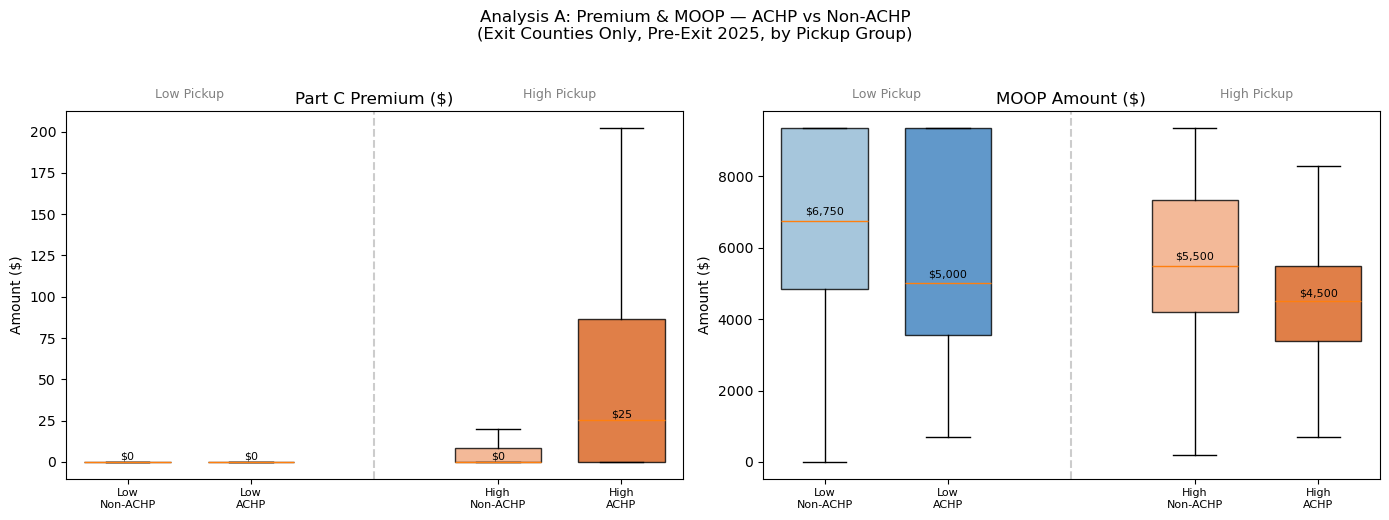

✓ analysis_A_premium_moop.png saved


In [ ]:
# ── A3. Numerical summary ──────────────────────────────────────────────
num_cols_exist = [c + "_num" for c in [premium_col, moop_col, combined_col]
                  if c + "_num" in df25_p.columns]

print("\n[Premium/MOOP mean] ACHP vs Non-ACHP, by Pickup group")
summary_A = (
    df25_p.groupby(["pickup_group", "is_achp"])[num_cols_exist]
    .mean().round(1)
)
summary_A.index = summary_A.index.map(
    lambda x: f"{x[0]} | {'ACHP' if x[1] else 'Non-ACHP'}"
)
print(summary_A.to_string())

# ── A4. Visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Analysis A: Premium & MOOP — ACHP vs Non-ACHP\n"
    "(Exit Counties Only, Pre-Exit 2025, by Pickup Group)",
    fontsize=12,
    y=1.03
)

for ax, col, title in zip(
    axes,
    [premium_col + "_num", moop_col + "_num"],
    ["Part C Premium ($)", "MOOP Amount ($)"]
):
    if col not in df25_p.columns:
        ax.set_title(f"{title}\n(column not found)")
        continue

    positions = [1, 2, 4, 5]
    labels    = ["Low\nNon-ACHP", "Low\nACHP", "High\nNon-ACHP", "High\nACHP"]
    colors    = ["#90B8D4", "#3A7FBD", "#F0A87E", "#D95F1A"]
    data_list = [
        df25_p[(df25_p["pickup_group"] == g) & (df25_p["is_achp"] == a)][col].dropna()
        for g, a in [("Low Pickup", False), ("Low Pickup", True),
                     ("High Pickup", False), ("High Pickup", True)]
    ]

    bp = ax.boxplot(data_list, positions=positions, patch_artist=True,
                    widths=0.7, showfliers=False)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Mean annotation
    for pos, d in zip(positions, data_list):
        if len(d) > 0:
            ax.text(pos, d.median() * 1.02, f"${d.median():,.0f}",
                    ha="center", va="bottom", fontsize=8)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Amount ($)")
    ax.axvline(3, color="gray", linestyle="--", alpha=0.4)
    ymax = ax.get_ylim()[1]
    ax.text(1.5, ymax * 1.03, "Low Pickup",
        ha="center", va="bottom", fontsize=9, color="gray", clip_on=False)
    ax.text(4.5, ymax * 1.03, "High Pickup",
        ha="center", va="bottom", fontsize=9, color="gray", clip_on=False)

plt.tight_layout()
plt.savefig("analysis_A_premium_moop.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ analysis_A_premium_moop.png saved")


## Analysis H1 Part 2: Plan Type Gap — What Exited vs What ACHP Offered

### Hypothesis
Counties with greater plan type similarity between exiting plans and ACHP offerings
should show higher ACHP pickup gains.

### What We Measure
- **Left chart**: plan type distribution of exiting plans in 2025, by pickup group
- **Right chart**: plan type distribution of ACHP plans offered in 2026, by pickup group
- **Three highlighted plan types**: PPO, HMO-POS, HMO D-SNP — the most strategically relevant

### Data Sources
- `plan_type_mix_viz`: exiting plan types from `exit_detail_B`, merged with `pickup_groups_viz`
- `df26`: 2026 Landscape file, filtered to ACHP contracts only, merged with `pickup_groups_viz`

### Key Comparisons
| Plan Type | High Pickup Exit | High Pickup ACHP | Gap |
|-----------|-----------------|------------------|-----|
| PPO | 44% | 33% | -11% |
| HMO-POS | 32% | 16% | -16% |
| HMO D-SNP | 8% | 8% | 0% |

| Plan Type | Low Pickup Exit | Low Pickup ACHP | Gap |
|-----------|----------------|-----------------|-----|
| HMO D-SNP | 24% | 41% | +17% |
| PPO | 15% | 14% | -1% |

### Expected vs Actual
| | Expected | Actual |
|--|----------|--------|
| Direction | Better match → higher pickup | Opposite: worse match → higher pickup |
| Interpretation | Product similarity drives pickup | Market vacuum drives pickup |


Analysis B: Plan Type Gap Analysis

[Exiting plan type share]
plan_type_grouped_viz    HMO  HMO C-SNP  HMO D-SNP  HMO-POS  HMO-POS D-SNP  Other    PPO
pickup_group                                                                            
Low Pickup             0.250      0.079      0.243    0.200          0.034  0.047  0.148
High Pickup            0.079      0.004      0.076    0.321          0.001  0.084  0.436

[ACHP 2026 plan type share (in exit counties)]
plan_type_grp26   Cost    HMO  HMO D-SNP  HMO I-SNP  HMO-POS  Other    PPO
pickup_group                                                              
Low Pickup       0.061  0.146      0.414      0.022    0.202  0.019  0.135
High Pickup      0.308  0.060      0.075      0.020    0.160  0.047  0.330


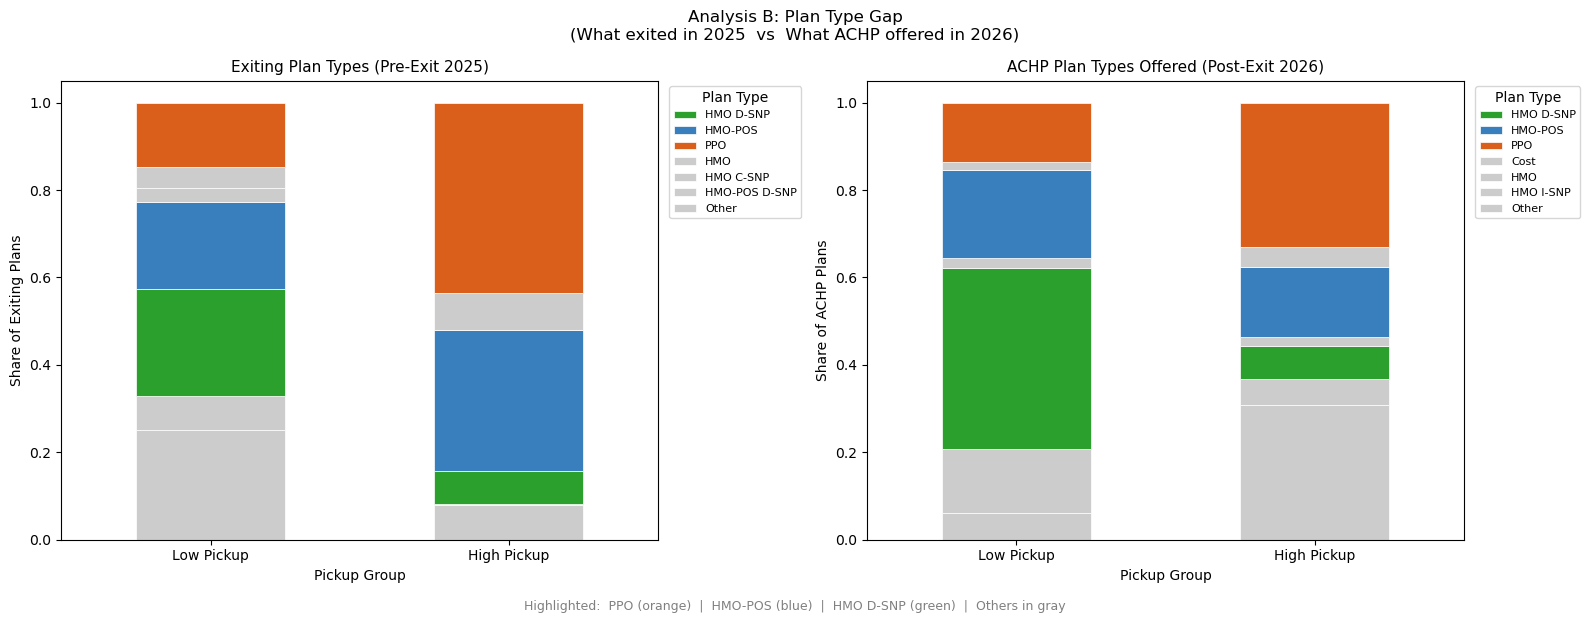

✓ analysis_B_plan_type_gap.png saved


In [ ]:

print("\n" + "=" * 60)
print("Analysis B: Plan Type Gap Analysis")
print("=" * 60)

# ── B1. Exiting plan type share ──────────────────────────────────────
exit_type_tab = pd.crosstab(
    plan_type_mix_viz["pickup_group"],
    plan_type_mix_viz["plan_type_grouped_viz"],
    normalize="index"
)
exit_type_tab = exit_type_tab.loc[
    [g for g in ["Low Pickup", "High Pickup"] if g in exit_type_tab.index]
]
print("\n[Exiting plan type share]")
print(exit_type_tab.round(3).to_string())

# ── B2. ACHP plan types offered in exit counties in 2026 ───────────
df26_p = df26.copy()
df26_p["is_achp"] = df26_p["Contract ID"].isin(achp_contracts)
df26_p["state_abbr_viz"] = df26_p["state_abbr"].astype(str).str.upper().str.strip()
df26_p["county_norm_viz"] = norm_county_for_viz(df26_p["county_norm"])

df26_achp = df26_p[df26_p["is_achp"]].merge(
    pickup_groups_viz[["state_abbr_viz", "county_norm_viz", "pickup_group"]],
    on=["state_abbr_viz", "county_norm_viz"],
    how="inner"
)

# Release immediately after use
del df26_p
import gc; gc.collect()

plan_col_26 = None
for c in ["Plan Type", "Plan Type "]:
    if c in df26_achp.columns:
        plan_col_26 = c
        break

achp_type_tab = None
if plan_col_26:
    df26_achp["plan_type_viz26"] = (
        df26_achp[plan_col_26].astype(str).str.strip()
        .replace({"": "Unknown", "nan": "Unknown"})
    )
    top_26 = df26_achp["plan_type_viz26"].value_counts().head(6).index.tolist()
    df26_achp["plan_type_grp26"] = np.where(
        df26_achp["plan_type_viz26"].isin(top_26),
        df26_achp["plan_type_viz26"], "Other"
    )
    achp_type_tab = pd.crosstab(
        df26_achp["pickup_group"],
        df26_achp["plan_type_grp26"],
        normalize="index"
    )
    achp_type_tab = achp_type_tab.loc[
        [g for g in ["Low Pickup", "High Pickup"] if g in achp_type_tab.index]
    ]
    print("\n[ACHP 2026 plan type share (in exit counties)]")
    print(achp_type_tab.round(3).to_string())

# ── B3. Color scheme: highlight three key types, others in gray ─────────────────
HIGHLIGHT_COLORS = {
    "PPO":          "#D95F1A",  # orange-red
    "HMO-POS":      "#3A7FBD",  # 蓝
    "HMO D-SNP":    "#2CA02C",  # 绿
}
GRAY = "#CCCCCC"  # All other types use this single gray color

def get_bar_colors(columns):
    return [
        HIGHLIGHT_COLORS.get(col, GRAY)
        for col in columns
    ]

def plot_stacked_bar(ax, tab, title, ylabel):
    """Draw stacked bar chart with unified colors"""
    colors = get_bar_colors(tab.columns)
    tab.plot(
        kind="bar", stacked=True, ax=ax,
        color=colors, edgecolor="white", linewidth=0.5
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Pickup Group")
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    # Legend: highlighted types listed first
    handles, labels = ax.get_legend_handles_labels()
    order = sorted(
        range(len(labels)),
        key=lambda i: (0 if labels[i] in HIGHLIGHT_COLORS else 1, labels[i])
    )
    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Plan Type",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=8
    )

# ── B4. Visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Analysis B: Plan Type Gap\n"
    "(What exited in 2025  vs  What ACHP offered in 2026)",
    fontsize=12
)

plot_stacked_bar(
    axes[0], exit_type_tab,
    "Exiting Plan Types (Pre-Exit 2025)",
    "Share of Exiting Plans"
)

if achp_type_tab is not None:
    plot_stacked_bar(
        axes[1], achp_type_tab,
        "ACHP Plan Types Offered (Post-Exit 2026)",
        "Share of ACHP Plans"
    )
else:
    axes[1].set_title("Plan Type column not found in df26")
    axes[1].axis("off")

# Bottom color legend
fig.text(
    0.5, -0.02,
    "Highlighted:  PPO (orange)  |  HMO-POS (blue)  |  HMO D-SNP (green)  "
    "|  Others in gray",
    ha="center", fontsize=9, color="gray"
)

plt.tight_layout()
plt.savefig("analysis_B_plan_type_gap.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ analysis_B_plan_type_gap.png saved")

## Analysis H2: Market Quality Change vs ACHP Pickup

### Hypothesis
Counties where lower-quality plans exited should show higher ACHP pickup —
as beneficiaries lose access to strong competitors and turn to ACHP as the next best option.

### What We Measure
- **avg_star_pre**: average Overall Star Rating across all plans in exit counties before exits (df25)
- **avg_star_post**: average Overall Star Rating across remaining plans after exits (df26)
- **star_delta**: post minus pre — positive = quality improved, negative = quality declined
- **pickup_group**: High Pickup vs Low Pickup, defined by top/bottom 25% of share_delta

### Method
- Paired t-test to assess whether star rating change is statistically significant
- Three charts:
  - Left: pre vs post star rating distribution across all exit counties
  - Middle: distribution of star_delta with mean reference line
  - Right: box plot of star_delta by High vs Low Pickup group

### Key Results
| Group | avg_star_pre | avg_star_post | star_delta |
|-------|-------------|---------------|------------|
| Low Pickup | 3.726 | 3.796 | +0.070 |
| High Pickup | 3.811 | 3.770 | -0.041 |
| Overall | 3.748 | 3.790 | +0.042 |

- Paired t-test: t = 7.530, p = 0.0000 — quality change is statistically significant
- High Pickup counties: IQR extending to -0.27 — strong competitors exited, market deteriorated
- Low Pickup counties: IQR mostly above zero — weak plans exited, market self-corrected

### Key Insight
Declining star ratings signal competitive vacuum formation — not market weakness.
Where strong plans exit, beneficiaries have fewer viable options and ACHP pickup follows.


Analysis C: Quality Cost (Market Star Rating Pre vs Post Exit)
2025 star rating field: Overall Star Rating
2026 star rating field: Overall Star Rating

All exit counties: pre-exit mean star 3.748 → post-exit mean star 3.790
Mean change: +0.042 星
Paired t-test: t = 7.530, p = 0.0000
→ Star rating change is statistically significant ✓

[Star rating change by Pickup group]
              avg_star_pre  avg_star_post  star_delta
pickup_group                                         
High Pickup          3.811          3.770      -0.041
Low Pickup           3.726          3.796       0.070


/var/folders/s7/j5wqf06d2bqfllwdjj1_xjvr0000gn/T/ipykernel_23054/619337805.py:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(box_data, labels=grps, patch_artist=True, showfliers=True)


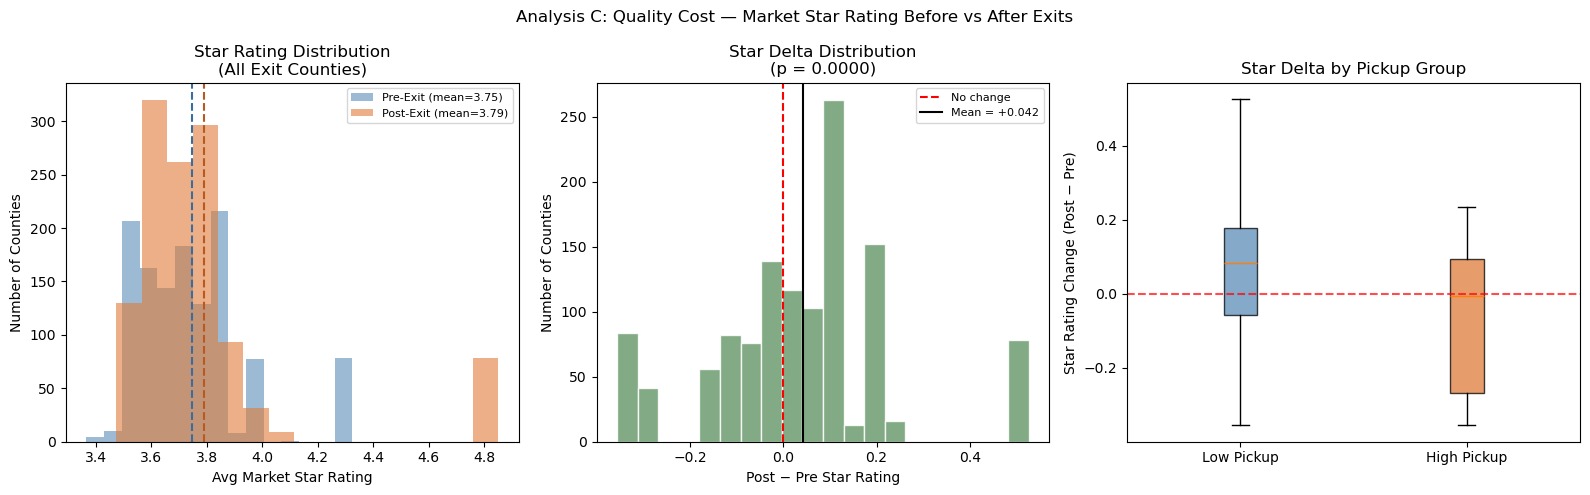

✓ analysis_C_quality_cost.png saved


In [ ]:

# ==============================================================
# Quality Cost：rating star
# ==============================================================

print("\n" + "=" * 60)
print("Analysis C: Quality Cost (Market Star Rating Pre vs Post Exit)")
print("=" * 60)

# Find star rating field
star_candidates = ["Overall Star Rating", "Overall Star Rating ",
                   "Part C Summary Star Rating", "Part C Summary Star Rating "]
star_col_25 = next((c for c in star_candidates if c in df25.columns), None)
star_col_26 = next((c for c in star_candidates if c in df26.columns), None)
print(f"2025 star rating field: {star_col_25}")
print(f"2026 star rating field: {star_col_26}")

if star_col_25 and star_col_26:

    # ── C1. Pre-exit: average star rating of all plans in county (including exiting ones)────────
    df25_s = df25.copy()
    df25_s["state_abbr_viz"] = df25_s["state_abbr"].astype(str).str.upper().str.strip()
    df25_s["county_norm_viz"] = norm_county_for_viz(df25_s["county_norm"])
    df25_s["star_num"] = clean_num(df25_s[star_col_25])

    # Keep only exit counties
    exit_pairs_viz = set(zip(
        county_change_exit_viz["state_abbr_viz"],
        county_change_exit_viz["county_norm_viz"]
    ))
    df25_s["is_exit"] = (
        list(zip(df25_s["state_abbr_viz"], df25_s["county_norm_viz"]))
    )
    df25_s["is_exit"] = df25_s["is_exit"].isin(exit_pairs_viz)

    pre_star = (
        df25_s[df25_s["is_exit"]]
        .groupby(["state_abbr_viz", "county_norm_viz"])["star_num"]
        .mean().reset_index(name="avg_star_pre")
    )

    # ── C2. Post-exit: average star rating of remaining plans (including ACHP) ─────────
    df26_s = df26.copy()
    df26_s["state_abbr_viz"] = df26_s["state_abbr"].astype(str).str.upper().str.strip()
    df26_s["county_norm_viz"] = norm_county_for_viz(df26_s["county_norm"])
    df26_s["star_num"] = clean_num(df26_s[star_col_26])
    df26_s["is_exit"] = (
        list(zip(df26_s["state_abbr_viz"], df26_s["county_norm_viz"]))
    )
    df26_s["is_exit"] = df26_s["is_exit"].isin(exit_pairs_viz)

    post_star = (
        df26_s[df26_s["is_exit"]]
        .groupby(["state_abbr_viz", "county_norm_viz"])["star_num"]
        .mean().reset_index(name="avg_star_post")
    )

    # ── C3. Merge and calculate change ────────────────────────────────────
    star_change = pre_star.merge(
        post_star, on=["state_abbr_viz", "county_norm_viz"], how="inner"
    )
    star_change["star_delta"] = star_change["avg_star_post"] - star_change["avg_star_pre"]
    star_change = star_change.merge(
        pickup_groups_viz[["state_abbr_viz", "county_norm_viz", "pickup_group"]],
        on=["state_abbr_viz", "county_norm_viz"], how="left"
    )

    overall_pre  = star_change["avg_star_pre"].mean()
    overall_post = star_change["avg_star_post"].mean()
    mean_delta   = star_change["star_delta"].mean()

    print(f"\nAll exit counties: pre-exit mean star {overall_pre:.3f} → post-exit mean star {overall_post:.3f}")
    print(f"Mean change: {mean_delta:+.3f} 星")

    t_stat, p_val = stats.ttest_rel(
        star_change["avg_star_post"].dropna(),
        star_change["avg_star_pre"].dropna()
    )
    print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
    print("→", "Star rating change is statistically significant ✓" if p_val < 0.05 else "Star rating change not significant (p > 0.05)")

    print("\n[Star rating change by Pickup group]")
    print(
        star_change.groupby("pickup_group")[["avg_star_pre", "avg_star_post", "star_delta"]]
        .mean().round(3).to_string()
    )

    # ── C4. Visualization ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        "Analysis C: Quality Cost — Market Star Rating Before vs After Exits",
        fontsize=12
    )

    # Left chart: pre vs post overall distribution
    axes[0].hist(star_change["avg_star_pre"].dropna(),
                 bins=15, alpha=0.6, color="#5B8DB8", label=f"Pre-Exit (mean={overall_pre:.2f})")
    axes[0].hist(star_change["avg_star_post"].dropna(),
                 bins=15, alpha=0.6, color="#E07B39", label=f"Post-Exit (mean={overall_post:.2f})")
    axes[0].axvline(overall_pre,  color="#3A6D9E", linestyle="--", linewidth=1.5)
    axes[0].axvline(overall_post, color="#B85A20", linestyle="--", linewidth=1.5)
    axes[0].set_title("Star Rating Distribution\n(All Exit Counties)")
    axes[0].set_xlabel("Avg Market Star Rating")
    axes[0].set_ylabel("Number of Counties")
    axes[0].legend(fontsize=8)

    # Middle chart: delta distribution
    axes[1].hist(star_change["star_delta"].dropna(), bins=20,
                 color="#6C9B6F", alpha=0.85, edgecolor="white")
    axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="No change")
    axes[1].axvline(mean_delta, color="black", linewidth=1.5,
                    label=f"Mean = {mean_delta:+.3f}")
    axes[1].set_title(f"Star Delta Distribution\n(p = {p_val:.4f})")
    axes[1].set_xlabel("Post − Pre Star Rating")
    axes[1].set_ylabel("Number of Counties")
    axes[1].legend(fontsize=8)

    # Right chart: box plot of star delta by High vs Low Pickup
    grps = [g for g in ["Low Pickup", "High Pickup"]
            if g in star_change["pickup_group"].values]
    box_data = [star_change[star_change["pickup_group"] == g]["star_delta"].dropna()
                for g in grps]
    bp = axes[2].boxplot(box_data, labels=grps, patch_artist=True, showfliers=True)
    for patch, col in zip(bp["boxes"], ["#5B8DB8", "#E07B39"]):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
    axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    axes[2].set_title("Star Delta by Pickup Group")
    axes[2].set_ylabel("Star Rating Change (Post − Pre)")

    plt.tight_layout()
    plt.savefig("analysis_C_quality_cost.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✓ analysis_C_quality_cost.png saved")

else:
    print("Warning: star rating field not found, skipping Analysis C")